# Lecture 3e — Classic Mean-Risk Optimisation with Riskfolio-Lib

### What this notebook is

A working tour of **Riskfolio-Lib**, the most complete open-source portfolio optimisation
library in Python. Where the rest of Lecture 3 built things by hand to expose the mechanics,
this notebook uses the production tool — including its own plotting functions, which are
genuinely good and hard to reproduce.

But a library tour is only worth an hour if it answers questions rather than listing features.
So we organise around three:

1. **What does the efficient frontier actually contain?** Not just its shape — its
   *composition*, and how that composition migrates as you accept more risk.
2. **Does the choice of risk measure matter?** Riskfolio offers thirteen. We will test whether
   optimising for drawdown genuinely delivers lower drawdown, or whether they all produce
   much the same portfolio wearing different labels.
3. **What do real-world constraints cost?** Sector caps and position limits are usually
   treated as an inconvenience. We will price them.

Before any of that, we fix the thing that stops most people getting started at all.

### What you will be able to do afterwards

1. Download price data for a list of tickers **without a few failures destroying your dataset**,
   and produce a coverage report explaining exactly what you got.
2. Use `rp.plot_frontier`, `rp.plot_frontier_area`, `rp.plot_risk_con` and `rp.plot_pie` fluently.
3. Choose a risk measure by matching it to the investor's actual concern, and test out of
   sample whether it delivered.
4. Express a realistic mandate through Riskfolio's constraint system and quantify its cost.

---

## 0. Setup

Riskfolio-Lib brings `cvxpy` with it, so this bootstrap is the slowest in the course. Its
plotting functions are matplotlib-based, which is why this notebook uses matplotlib rather
than the Plotly style used elsewhere in Lecture 3 — the whole point is to use the library's
own tools.

In [1]:
# =====================================================================
#  AIRM Lecture 3e — bootstrap.  Run once.
# =====================================================================
import sys, subprocess, warnings, time, urllib.request
from pathlib import Path
warnings.filterwarnings("ignore")

def _has(p):
    try: __import__({"riskfolio-lib": "riskfolio"}.get(p, p)); return True
    except ImportError: return False
def ensure(pkgs):
    missing = [p for p in pkgs if not _has(p)]
    if missing:
        print(f"Installing {', '.join(missing)} ... (can take a couple of minutes)")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

ensure(["pandas", "numpy", "matplotlib", "yfinance", "riskfolio-lib"])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import riskfolio as rp
import yfinance as yf

# --- matplotlib 3.11 compatibility shim for Riskfolio-Lib 7.3 -------------
# matplotlib removed cm.get_cmap in 3.11 (deprecated since 3.7). Riskfolio's
# plot_frontier_area, plot_pie and plot_series still call it. Restore it.
import matplotlib
import matplotlib.cm as cm

if not hasattr(cm, "get_cmap"):
    def _get_cmap(name=None, lut=None):
        if name is None:
            name = matplotlib.rcParams["image.cmap"]
        if isinstance(name, matplotlib.colors.Colormap):
            return name
        cmap = matplotlib.colormaps[name]
        return cmap.resampled(lut) if lut is not None else cmap
    cm.get_cmap = _get_cmap

from matplotlib.axes import Axes
if not hasattr(Axes, "plot_date"):
    Axes.plot_date = lambda self, x, y, *a, **kw: self.plot(x, y, *a, **kw)
    

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 120)

def show():
    """plt.show(), tolerant of Riskfolio's colorbars.

    rp.plot_frontier attaches a colorbar, and current matplotlib raises
    RuntimeError if tight_layout() is called on a figure that already has one.
    Catch it rather than let a cosmetic call break the cell.
    """
    try:
        plt.tight_layout()
    except RuntimeError:
        pass
    plt.show()

print(f"Riskfolio-Lib {rp.__version__} | yfinance {yf.__version__} | pandas {pd.__version__}")

Riskfolio-Lib 7.3.0 | yfinance 1.5.2 | pandas 3.0.5


In [2]:
def _flatten_columns(df, requested):
    """yfinance returns a MultiIndex for multi-ticker requests and changed the level
    order in 2024. Reduce whatever we received to plain ticker columns."""
    if isinstance(df.columns, pd.MultiIndex):
        for level in range(df.columns.nlevels):
            if set(df.columns.get_level_values(level)) & set(requested):
                df = df.copy(); df.columns = df.columns.get_level_values(level); break
        else:
            df = df.copy(); df.columns = df.columns.get_level_values(-1)
    return df.loc[:, ~df.columns.duplicated()]


def download_prices(tickers, start, end, downloader=None, max_retries=2,
                    batch_size=8, min_coverage=0.95, pause=1.0, verbose=True):
    """Download adjusted closes without letting a few failures destroy the dataset.

    1. Fetch in SMALL BATCHES rather than one big parallel request -- large parallel
       requests are what trigger Yahoo's rate limiter.
    2. RETRY failures individually, with a growing pause. Most "delisted" tickers
       are simply throttled and come back on the second attempt.
    3. Drop all-NaN columns BEFORE dropping any rows. This is the critical ordering:
       one empty column will otherwise delete every row in the frame.
    4. Drop tickers whose history is too short to be comparable.
    5. Forward-fill isolated single-day gaps rather than deleting that date for
       every other stock.

    Returns (prices, report). The report has one row per REQUESTED ticker.
    """
    if downloader is None:
        def downloader(tks, start, end):
            return yf.download(tks, start=start, end=end, auto_adjust=True,
                               progress=False, threads=False)["Close"]

    tickers = list(dict.fromkeys(tickers))
    frames, status = {}, {}

    def _attempt(batch, label):
        try:
            got = downloader(batch, start, end)
        except Exception as exc:
            for t in batch: status[t] = f"error: {type(exc).__name__}"
            return
        if isinstance(got, pd.Series):
            got = got.to_frame(batch[0])
        got = _flatten_columns(got, batch)
        for t in batch:
            if t in got.columns and got[t].notna().any():
                frames[t] = got[t]; status[t] = "ok" if label == "first" else "ok (on retry)"
            else:
                status.setdefault(t, "no data returned")

    for i in range(0, len(tickers), batch_size):
        _attempt(tickers[i:i+batch_size], "first")
        if pause: time.sleep(pause)

    for attempt in range(max_retries):
        missing = [t for t in tickers if t not in frames]
        if not missing: break
        if verbose: print(f"  retry {attempt+1}: {', '.join(missing)}")
        for t in missing:
            _attempt([t], "retry")
            if pause: time.sleep(pause * (attempt + 1))

    if not frames:
        raise RuntimeError("No tickers downloaded. Check connection, dates and symbols.")

    raw = pd.DataFrame(frames).sort_index()
    span = len(raw)
    rows = []
    for t in tickers:
        if t not in raw.columns:
            rows.append({"ticker": t, "status": status.get(t, "failed"),
                         "first": None, "last": None, "n_obs": 0, "coverage": 0.0})
        else:
            s = raw[t].dropna()
            rows.append({"ticker": t, "status": status.get(t, "ok"),
                         "first": s.index.min(), "last": s.index.max(),
                         "n_obs": len(s), "coverage": len(s)/span if span else 0.0})
    report = pd.DataFrame(rows).set_index("ticker")

    prices = raw.dropna(axis=1, how="all")                     # empty columns first
    short = [t for t in report.index[(report["coverage"] < min_coverage) &
                                     (report["coverage"] > 0)] if t in prices.columns]
    if short:
        prices = prices.drop(columns=short)
        report.loc[short, "status"] = "dropped: short history"
    prices = prices.ffill(limit=3).dropna()                    # patch gaps, then drop rows
    report["used"] = report.index.isin(prices.columns)

    if verbose:
        n_ok = int(report["used"].sum())
        print(f"\n  requested {len(tickers)} | usable {n_ok} | "
              f"excluded {len(tickers)-n_ok} | {len(prices)} common dates")
        for t, r in report[~report["used"]].iterrows():
            print(f"    excluded {t:8s} {r['status']}")
    return prices, report

print("Loader defined.")

Loader defined.


### Get the data

Edit `TICKERS` freely — the loader will tell you what it could and could not fetch rather than
failing silently. `MMC` and `SEE` are deliberately left in so you can watch the retry logic
handle exactly the case that broke the original notebook.

In [3]:
TICKERS = ["AAPL", "MSFT", "AMZN", "GOOGL", "META",      # technology / communication
           "JPM",  "BAC",  "GS",                          # financials
           "JNJ",  "PFE",  "UNH",                         # health care
           "XOM",  "CVX",                                 # energy
           "PG",   "KO",   "WMT",  "COST",                # staples
           "HD",   "MCD",                                 # discretionary
           "CAT",  "HON",  "MMC",                         # industrials
           "NEE",  "SO",                                  # utilities
           "SEE"]                                         # materials

START, END = "2018-01-01", "2023-12-31"

print(f"Requesting {len(TICKERS)} tickers, {START} to {END}\n")
prices, report = download_prices(TICKERS, START, END)
returns = prices.pct_change().dropna()

print(f"\nReturns matrix: {returns.shape}")

Requesting 25 tickers, 2018-01-01 to 2023-12-31



$MMC: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['MMC']: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")
$SEE: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['SEE']: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")
$MMC: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['MMC']: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")


  retry 1: MMC, SEE


$SEE: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['SEE']: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")
$MMC: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['MMC']: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")


  retry 2: MMC, SEE


$SEE: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['SEE']: possibly delisted; no price data found  (1d 2018-01-01 -> 2023-12-31) (Yahoo error = "No data found, symbol may be delisted")



  requested 25 | usable 23 | excluded 2 | 1509 common dates
    excluded MMC      no data returned
    excluded SEE      no data returned

Returns matrix: (1508, 23)


In [4]:
# The coverage report -- read this before trusting any optimisation downstream.
coverage_table = report.copy()
coverage_table["coverage"] = coverage_table["coverage"].map("{:.1%}".format)
for c in ["first", "last"]:
    coverage_table[c] = pd.to_datetime(coverage_table[c]).dt.strftime("%Y-%m-%d").fillna("—")
display(coverage_table[["status", "first", "last", "n_obs", "coverage", "used"]])

print(f"\nUsable universe ({int(report['used'].sum())} assets): {', '.join(prices.columns)}")
if (~report["used"]).any():
    print("\nExcluded, with reasons shown above. The optimisation proceeds on the rest —")
    print("which is the whole point: a couple of bad symbols must not stop your research.")

,status,first,last,n_obs,coverage,used
ticker,,,,,,
AAPL,ok,2018-01-02,2023-12-29,1509,100.0%,True
MSFT,ok,2018-01-02,2023-12-29,1509,100.0%,True
AMZN,ok,2018-01-02,2023-12-29,1509,100.0%,True
GOOGL,ok,2018-01-02,2023-12-29,1509,100.0%,True
META,ok,2018-01-02,2023-12-29,1509,100.0%,True
JPM,ok,2018-01-02,2023-12-29,1509,100.0%,True
BAC,ok,2018-01-02,2023-12-29,1509,100.0%,True
GS,ok,2018-01-02,2023-12-29,1509,100.0%,True
JNJ,ok,2018-01-02,2023-12-29,1509,100.0%,True



Usable universe (23 assets): AAPL, MSFT, AMZN, GOOGL, META, JPM, BAC, GS, JNJ, PFE, UNH, XOM, CVX, PG, KO, WMT, COST, HD, MCD, CAT, HON, NEE, SO

Excluded, with reasons shown above. The optimisation proceeds on the rest —
which is the whole point: a couple of bad symbols must not stop your research.


<details>
<summary><b>Design notes on the loader</b></summary>

**Why `threads=False`?** Parallel requests are faster but far more likely to trip Yahoo's rate
limiter. Since we are batching anyway, sequential requests inside each batch trade a little
speed for a lot of reliability.

**Why forward-fill with `limit=3`?** A single missing day for one stock (a trading halt, a
local holiday) should not delete that date for all the others. Filling up to three consecutive
days handles genuine gaps while refusing to invent a week of prices. A filled price produces a
zero return for that day, which slightly understates volatility — acceptable for a handful of
days, not for more.

**Why drop short-history tickers rather than truncate everyone?** Truncating the sample to the
common window means one recent IPO can throw away years of history for every other asset. With
`min_coverage=0.95` we keep the long sample and lose the newcomer. Set it to `0` to keep
everything and truncate instead.

**A caution on `auto_adjust`.** yfinance changed this default to `True` in 2024. Adjusted
prices incorporate dividends and splits, which is what you want for return calculations —
but it means the "Close" you see will not match the raw closing price quoted elsewhere.

</details>

---

# The Portfolio object

Riskfolio's workflow is always the same three steps: create a `Portfolio`, estimate its
statistics, then optimise. Everything else is variation on those.

In [5]:
port = rp.Portfolio(returns=returns)

# Ledoit-Wolf shrinkage rather than the raw sample covariance -- Lecture 3c showed why.
port.assets_stats(method_mu="hist", method_cov="ledoit")

w_sharpe = port.optimization(model="Classic", rm="MV", obj="Sharpe", rf=0, l=0, hist=True)
w_minrisk = port.optimization(model="Classic", rm="MV", obj="MinRisk", rf=0, l=0, hist=True)

summary = pd.DataFrame({"Max Sharpe": w_sharpe.iloc[:, 0],
                        "Min risk": w_minrisk.iloc[:, 0]})
summary["difference"] = summary["Max Sharpe"] - summary["Min risk"]
print("Two portfolios from the same inputs:\n")
print(summary.sort_values("Max Sharpe", ascending=False).head(10).to_string(
    formatters={c: "{:.2%}".format for c in summary.columns}))

for name, w in [("Max Sharpe", w_sharpe), ("Min risk", w_minrisk)]:
    v = w.values.ravel()
    r_ann = float(port.mu.values.ravel() @ v) * 252
    s_ann = float(np.sqrt(v @ port.cov.values @ v)) * np.sqrt(252)
    print(f"\n{name:11s} return {r_ann:6.2%}  vol {s_ann:6.2%}  "
          f"Sharpe {r_ann/s_ann:.2f}  holdings>1% {(v>0.01).sum():2d}  "
          f"effective N {1/np.sum(v**2):.1f}")

Two portfolios from the same inputs:

     Max Sharpe Min risk difference
COST     49.53%    3.27%     46.26%
MSFT     19.97%    0.00%     19.97%
AAPL     17.55%    0.00%     17.55%
UNH       5.53%    0.00%      5.53%
SO        4.77%    0.00%      4.77%
CAT       2.65%    0.00%      2.65%
MCD       0.00%   15.10%    -15.10%
XOM       0.00%    4.48%     -4.48%
PG        0.00%   10.32%    -10.32%
NEE       0.00%    0.00%     -0.00%

Max Sharpe  return 26.34%  vol 21.85%  Sharpe 1.21  holdings>1%  6  effective N 3.1

Min risk    return 11.22%  vol 15.83%  Sharpe 0.71  holdings>1%  9  effective N 7.0


---

# Module A — The frontier, and what is inside it

## `rp.plot_frontier`

The frontier is computed once and then plotted, with the max-Sharpe portfolio marked via the
`w=` argument. Colour along the curve encodes the Sharpe ratio.

Frontier: 23 assets x 40 portfolios


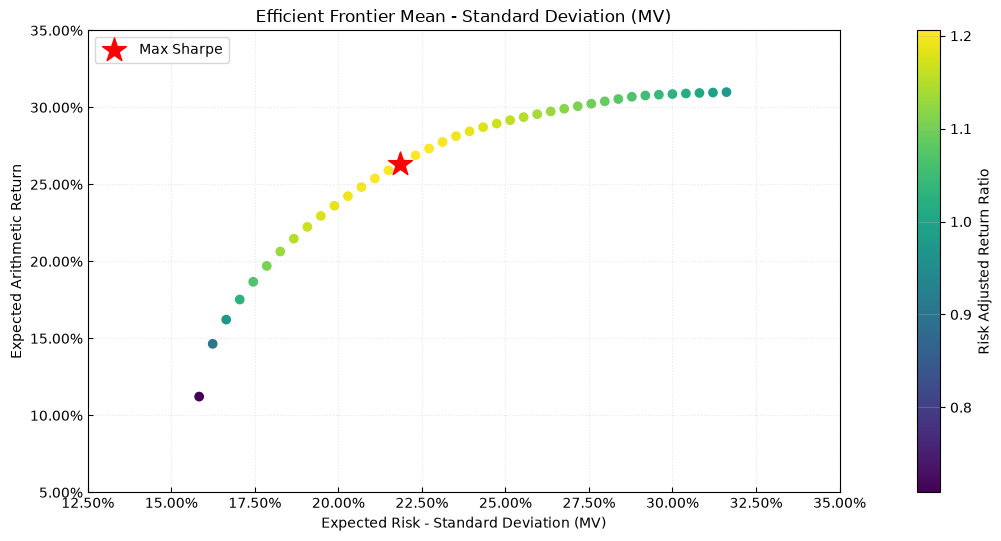

In [6]:
POINTS = 40
frontier = port.efficient_frontier(model="Classic", rm="MV", points=POINTS, rf=0, hist=True)
print(f"Frontier: {frontier.shape[0]} assets x {frontier.shape[1]} portfolios")

ax = rp.plot_frontier(w_frontier=frontier, mu=port.mu, cov=port.cov, returns=returns,
                      rm="MV", rf=0, alpha=0.05, cmap="viridis",
                      w=w_sharpe, label="Max Sharpe", marker="*", s=18, c="r",
                      height=6, width=11, t_factor=252)
show()

## `rp.plot_frontier_area` — the part people skip

This is the most underused plot in the library. It shows the frontier's **composition**: each
band is an asset, and reading left to right shows how the portfolio changes as you accept more
risk.

Straight out of the box it is not very informative, because the bands are in whatever order
the assets happen to be listed and there are too many colours to track. **One change fixes
it**: sort the assets by sector first, so bands from the same sector sit adjacent. Then the
plot stops being a colour chart and starts telling a story.

In [ ]:
SECTOR_MAP = {
    "AAPL": "Technology", 
    "MSFT": "Technology", 
    "AMZN": "Discretionary",
    "GOOGL": "Communication", 
    "META": "Communication",
    "JPM": "Financials", 
    "BAC": "Financials", 
    "GS": "Financials",
    "JNJ": "Health Care", 
    "PFE": "Health Care", 
    "UNH": "Health Care",
    "XOM": "Energy", 
    "CVX": "Energy",
    "PG": "Staples", 
    "KO": "Staples", 
    "WMT": "Staples", 
    "COST": "Staples",
    "HD": "Discretionary", 
    "MCD": "Discretionary",
    "CAT": "Industrials", 
    "HON": "Industrials", 
    "MMC": "Industrials",
    "NEE": "Utilities", 
    "SO": "Utilities", 
    "SEE": "Materials",
}

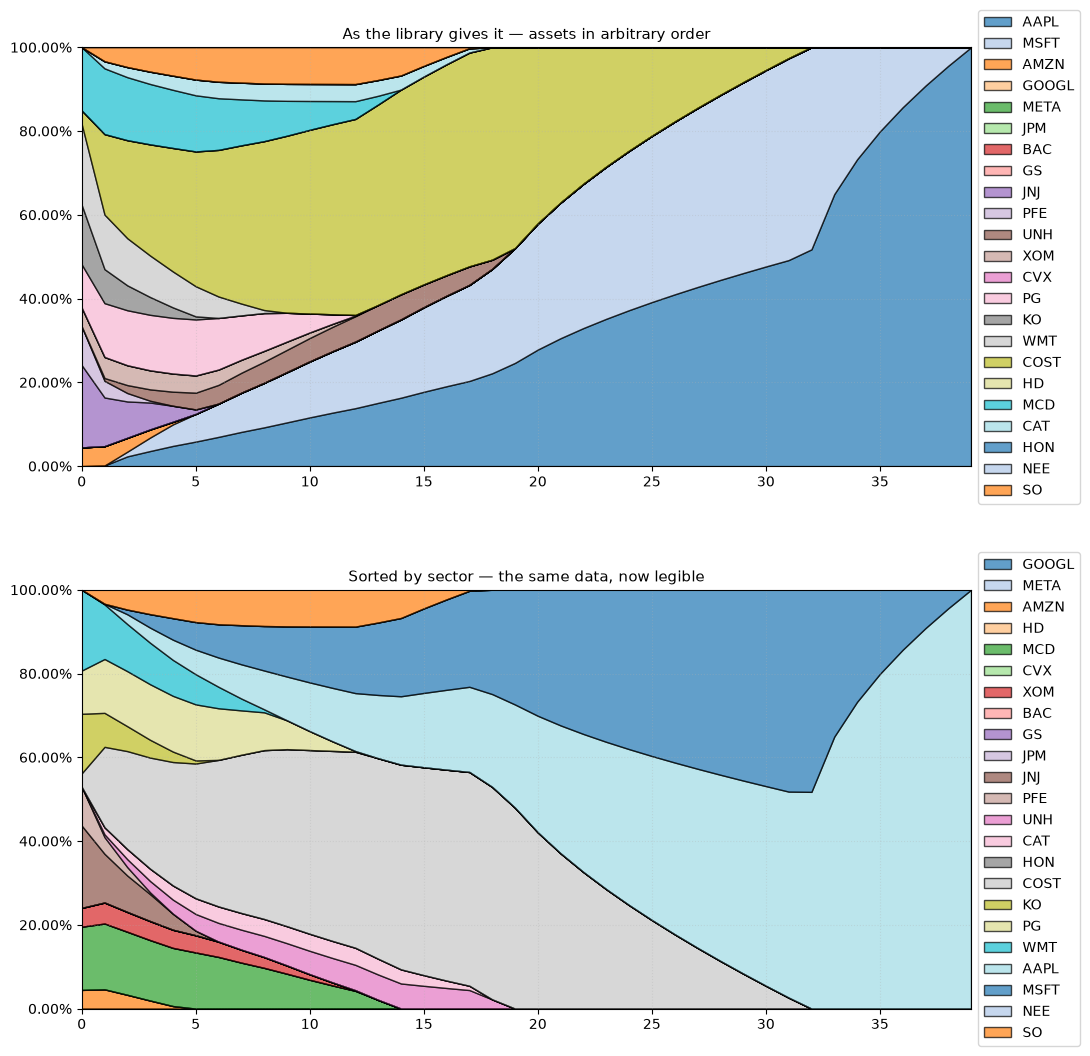

In [9]:
sector_of = {t: SECTOR_MAP.get(t, "Other") for t in frontier.index}

# Sort assets by sector so the stacked bands group into readable blocks.
ordered = sorted(frontier.index, key=lambda t: (sector_of[t], t))
frontier_sorted = frontier.loc[ordered]

fig, axes = plt.subplots(2, 1, figsize=(11, 11))
rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", n_colors=20, ax=axes[0])
axes[0].set_title("As the library gives it — assets in arbitrary order", fontsize=11)
rp.plot_frontier_area(w_frontier=frontier_sorted, cmap="tab20", n_colors=20, ax=axes[1])
axes[1].set_title("Sorted by sector — the same data, now legible", fontsize=11)
show()

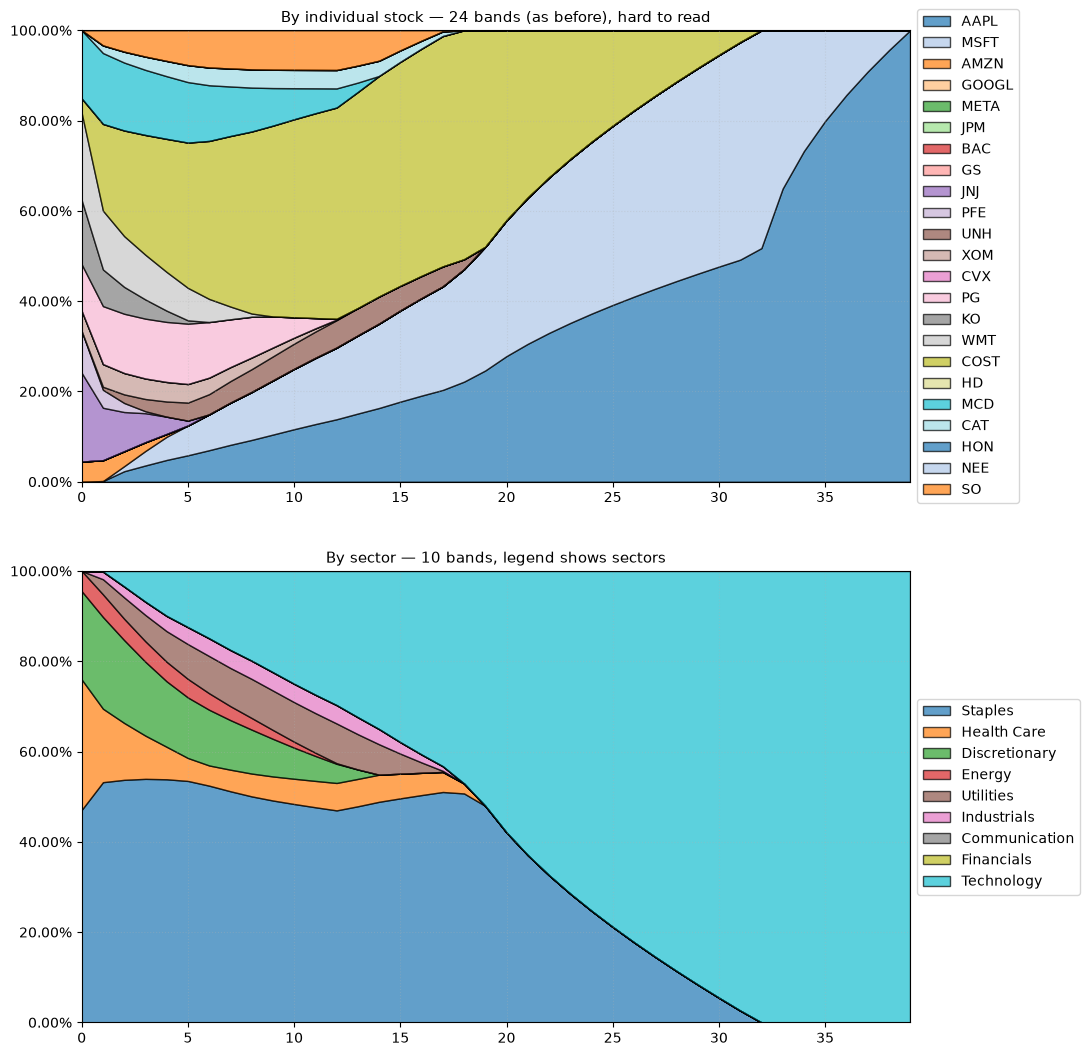

In [11]:
# Collapse stock weights into sector weights: 24 rows -> 10 rows
frontier_sectors = frontier.groupby(sector_of).sum()

# Order so the stack reads defensive (bottom) -> aggressive (top)
migration = frontier_sectors.iloc[:, -1] - frontier_sectors.iloc[:, 0]
frontier_sectors = frontier_sectors.loc[migration.sort_values().index]

fig, axes = plt.subplots(2, 1, figsize=(11, 11))

rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", n_colors=20, ax=axes[0]) # add "nrow = 5", for example, to have the legend span into several columns if it is too long
axes[0].set_title("By individual stock — 24 bands (as before), hard to read", fontsize=11)

rp.plot_frontier_area(w_frontier=frontier_sectors, cmap="tab10",
                      n_colors=len(frontier_sectors), nrow=10, ax=axes[1])
axes[1].set_title("By sector — 10 bands, legend shows sectors", fontsize=11)

show()

In [12]:
# Quantify the migration: sector weights at each end of the frontier.
sec_series = pd.Series(sector_of)
low_risk  = frontier_sorted.iloc[:, 0].groupby(sec_series).sum()
high_risk = frontier_sorted.iloc[:, -1].groupby(sec_series).sum()
mid       = frontier_sorted.iloc[:, POINTS//2].groupby(sec_series).sum()

migration = pd.DataFrame({"Low risk end": low_risk, "Middle": mid,
                          "High risk end": high_risk})
migration["Change"] = migration["High risk end"] - migration["Low risk end"]
migration = migration.sort_values("Change")
print("Sector composition along the frontier:\n")
print(migration.to_string(formatters={c: "{:.1%}".format for c in migration.columns}))

n_held_lo = int((frontier_sorted.iloc[:, 0] > 0.01).sum())
n_held_hi = int((frontier_sorted.iloc[:, -1] > 0.01).sum())
print(f"\nAssets held at the low-risk end : {n_held_lo}")
print(f"Assets held at the high-risk end: {n_held_hi}")
print("\nThe high-risk end of ANY mean-variance frontier collapses towards a corner")
print("solution -- ultimately the single highest-return asset, because nothing else can")
print("reach that return. Diversification is a property of the LEFT of the frontier.")

Sector composition along the frontier:

              Low risk end Middle High risk end Change
Staples              47.1%  42.1%          0.0% -47.1%
Health Care          28.9%   0.0%          0.0% -28.9%
Discretionary        19.6%   0.0%          0.0% -19.6%
Energy                4.5%   0.0%          0.0%  -4.5%
Utilities             0.0%   0.0%          0.0%  -0.0%
Industrials           0.0%   0.0%          0.0%  -0.0%
Communication         0.0%   0.0%          0.0%  -0.0%
Financials            0.0%   0.0%          0.0%  -0.0%
Technology            0.0%  57.9%        100.0% 100.0%

Assets held at the low-risk end : 9
Assets held at the high-risk end: 1

The high-risk end of ANY mean-variance frontier collapses towards a corner
solution -- ultimately the single highest-return asset, because nothing else can
reach that return. Diversification is a property of the LEFT of the frontier.


Read the migration table and the two charts together. Three things are visible that the
default plot hides:

**The low-risk end is diversified; the high-risk end is not.** As you demand more return, the
optimiser progressively abandons assets until it holds only the highest-return name it can
find. This is not a quirk of our data — it is structural. The maximum-return point of *any*
mean-variance frontier is a corner solution holding one asset, because no combination can
exceed the best single return.

**Defensive sectors sit on the left.** Staples, utilities and health care dominate the
low-risk end. That is the frontier telling you what "low risk" meant over this sample.

**The middle is where portfolios actually live.** Nobody runs the extreme ends. The
interesting region is where composition is still changing but diversification survives — and
that region is only visible in the area plot.

---

# Module E — Kelly, in one argument

`plot_frontier` accepts `kelly=True`, which switches the return axis from arithmetic mean to
the **logarithmic growth rate** — the objective of the Kelly criterion, which maximises
long-run compound wealth rather than one-period expected return.

The distinction matters because compounding is not linear: a portfolio that gains 50% then
loses 50% has an arithmetic mean return of zero and has actually lost 25% of its capital.

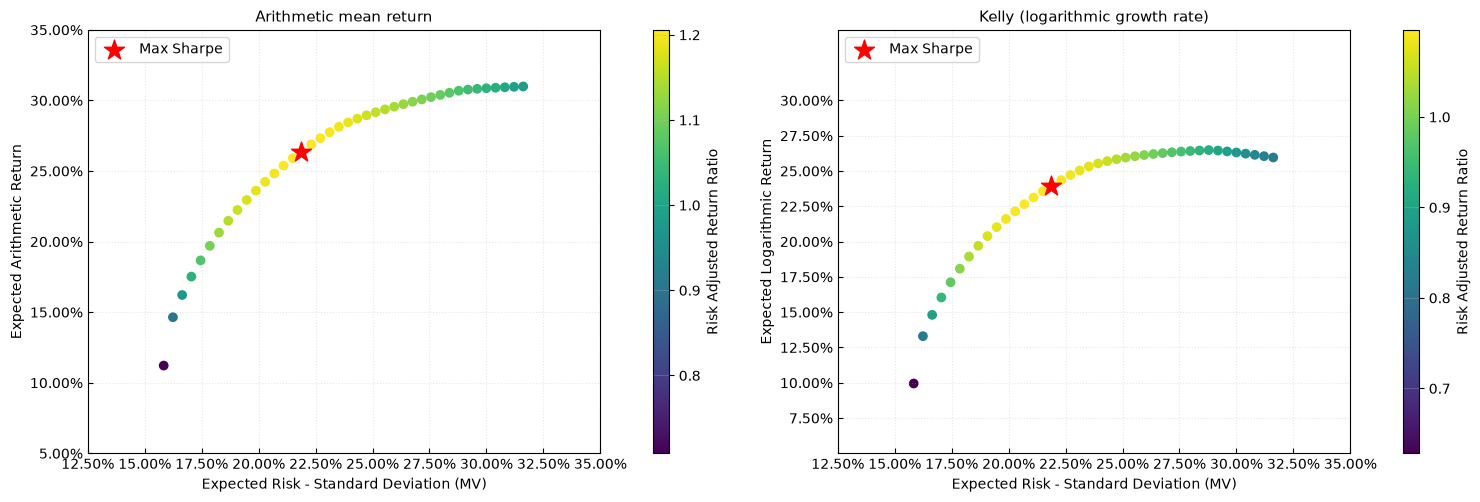

The Kelly frontier bends DOWN relative to the arithmetic one, and the gap widens
with risk. That gap is the VOLATILITY DRAG -- roughly σ²/2 -- the difference between
what you average and what you actually compound. High-volatility portfolios look
materially worse once you judge them by growth rather than by mean return.


In [13]:
common = dict(w_frontier=frontier, mu=port.mu, cov=port.cov, returns=returns,
              rm="MV", rf=0, cmap="viridis", w=w_sharpe, label="Max Sharpe",
              marker="*", s=15, c="r", t_factor=252)

fig = plt.figure(figsize=(15, 5.5))
left, right = fig.subfigures(1, 2)

rp.plot_frontier(ax=left.subplots(),  **common)
rp.plot_frontier(ax=right.subplots(), kelly=True, **common)

# index 1 is the chart Riskfolio actually drew on (0 = hidden, 2 = colorbar)
ax0, ax1 = left.axes[1], right.axes[1]

ax0.set_title("Arithmetic mean return", fontsize=11)
ax1.set_title("Kelly (logarithmic growth rate)", fontsize=11)

# common y range across both panels — must come AFTER the plot calls,
# because plot_frontier sets its own limits with a 10% pad
lo = min(ax0.get_ylim()[0], ax1.get_ylim()[0])
hi = max(ax0.get_ylim()[1], ax1.get_ylim()[1])
for a in (ax0, ax1):
    a.set_ylim(lo, hi)

plt.show()
print("The Kelly frontier bends DOWN relative to the arithmetic one, and the gap widens")
print("with risk. That gap is the VOLATILITY DRAG -- roughly σ²/2 -- the difference between")
print("what you average and what you actually compound. High-volatility portfolios look")
print("materially worse once you judge them by growth rather than by mean return.")

---

# Module B — The risk-measure tournament

Riskfolio's headline feature is that `rm=` accepts thirteen different definitions of risk.
Listing them is not insight. The useful move is to ask **what investor question each one
answers**, and then test whether it delivers.

| `rm` | Name | The question it answers |
|---|---|---|
| `MV` | Variance | How much does it wobble? |
| `MAD` | Mean absolute deviation | Same, but less spooked by outliers |
| `MSV` | Semi-variance | How much does it wobble *downwards*? |
| `CVaR` | Conditional VaR | How bad is an average bad day? |
| `EVaR` | Entropic VaR | Same, weighting extremes more heavily |
| `WR` | Worst realisation | How bad was the single worst day? |
| `MDD` | Maximum drawdown | How deep was the worst hole? |
| `ADD` | Average drawdown | How deep is a typical hole? |
| `CDaR` | Conditional drawdown at risk | How deep are the bad holes on average? |
| `UCI` | Ulcer index | How long and painful were the holes? |
| `EDaR` | Entropic drawdown at risk | Tail-weighted version of the same |

They fall into four families — **dispersion**, **downside**, **tail** and **drawdown** — and
the obvious hypothesis is that a portfolio optimised for drawdown should suffer shallower
drawdowns than one optimised for variance.

That is testable. So we test it, out of sample.

In [14]:
SPLIT = 0.60
k = int(len(returns) * SPLIT)
train, test = returns.iloc[:k], returns.iloc[k:]
print(f"TRAIN {train.index.min():%b %Y} to {train.index.max():%b %Y} ({len(train)} days)")
print(f"TEST  {test.index.min():%b %Y} to {test.index.max():%b %Y} ({len(test)} days)")

RISK_FAMILY = {
    "MV": "dispersion", "MAD": "dispersion",
    "MSV": "downside",  "FLPM": "downside",
    "CVaR": "tail",     "EVaR": "tail",   "WR": "tail",
    "MDD": "drawdown",  "ADD": "drawdown", "CDaR": "drawdown",
    "UCI": "drawdown",  "EDaR": "drawdown",
}

port_tr = rp.Portfolio(returns=train)
port_tr.assets_stats(method_mu="hist", method_cov="ledoit")

def out_of_sample(weights, rets=test):
    r = rets.values @ np.asarray(weights).ravel()
    curve = (1 + r).cumprod()
    tail = np.sort(r)[:max(int(0.05 * len(r)), 1)]
    return {"Sharpe": r.mean()/r.std()*np.sqrt(252),
            "Volatility": r.std()*np.sqrt(252),
            "Max drawdown": (curve/np.maximum.accumulate(curve) - 1).min(),
            "CVaR 5%": tail.mean()*np.sqrt(252)}

rows, weight_book = [], {}
for rm, family in RISK_FAMILY.items():
    try:
        w = port_tr.optimization(model="Classic", rm=rm, obj="Sharpe", rf=0, l=0, hist=True)
        if w is None:
            print(f"  {rm}: no solution"); continue
        v = w.values.ravel()
        weight_book[rm] = v
        rec = out_of_sample(v); rec.update({"rm": rm, "family": family,
                                            "Effective N": 1/np.sum(v**2)})
        rows.append(rec)
    except Exception as e:
        print(f"  {rm}: failed ({type(e).__name__})")

eq = np.ones(returns.shape[1]) / returns.shape[1]
rec = out_of_sample(eq); rec.update({"rm": "Equal weight", "family": "naive",
                                     "Effective N": 1/np.sum(eq**2)})
rows.append(rec)

tourney = pd.DataFrame(rows).set_index("rm")
display(tourney[["family", "Sharpe", "Volatility", "Max drawdown", "CVaR 5%", "Effective N"]]
        .style.format({"Sharpe": "{:.2f}", "Volatility": "{:.2%}",
                       "Max drawdown": "{:.1%}", "CVaR 5%": "{:.1%}",
                       "Effective N": "{:.1f}"})
        .background_gradient(subset=["Max drawdown"], cmap="RdYlGn"))

TRAIN Jan 2018 to Aug 2021 (904 days)
TEST  Aug 2021 to Dec 2023 (604 days)


,family,Sharpe,Volatility,Max drawdown,CVaR 5%,Effective N
rm,,,,,,
MV,dispersion,0.57,21.95%,-25.2%,-50.0%,4.1
MAD,dispersion,0.56,21.12%,-23.8%,-47.5%,4.0
MSV,downside,0.59,21.71%,-25.1%,-49.4%,3.5
FLPM,downside,0.57,20.99%,-23.7%,-47.3%,3.9
CVaR,tail,0.55,21.77%,-25.2%,-49.5%,3.6
EVaR,tail,0.45,27.92%,-36.8%,-63.2%,2.4
WR,tail,0.53,26.97%,-34.6%,-61.4%,1.9
MDD,drawdown,0.81,23.67%,-26.0%,-54.2%,2.0
ADD,drawdown,0.58,19.20%,-23.7%,-42.4%,4.1


In [15]:
# The test: does each FAMILY deliver the thing it optimises for?
by_family = tourney.groupby("family")[["Sharpe", "Volatility", "Max drawdown"]].mean()
by_family = by_family.sort_values("Max drawdown", ascending=False)
print("Average OUT-OF-SAMPLE outcome by risk-measure family:\n")
print(by_family.to_string(formatters={"Sharpe": "{:.2f}".format,
                                      "Volatility": "{:.2%}".format,
                                      "Max drawdown": "{:.1%}".format}))

dd = by_family.loc["drawdown", "Max drawdown"] if "drawdown" in by_family.index else np.nan
dp = by_family.loc["dispersion", "Max drawdown"] if "dispersion" in by_family.index else np.nan
naive = by_family.loc["naive", "Max drawdown"] if "naive" in by_family.index else np.nan

print(f"\nDrawdown-family average max drawdown : {dd:.1%}")
print(f"Dispersion-family average            : {dp:.1%}")
verdict = "DELIVERED" if dd > dp else "did NOT deliver"
print(f"-> optimising for drawdown {verdict} shallower drawdowns out of sample.")
print(f"\nEqual weight                         : {naive:.1%}")

Average OUT-OF-SAMPLE outcome by risk-measure family:

           Sharpe Volatility Max drawdown
family                                   
naive        0.59     16.00%       -17.0%
downside     0.58     21.35%       -24.4%
dispersion   0.56     21.54%       -24.5%
drawdown     0.71     21.89%       -25.6%
tail         0.51     25.55%       -32.2%

Drawdown-family average max drawdown : -25.6%
Dispersion-family average            : -24.5%
-> optimising for drawdown did NOT deliver shallower drawdowns out of sample.

Equal weight                         : -17.0%


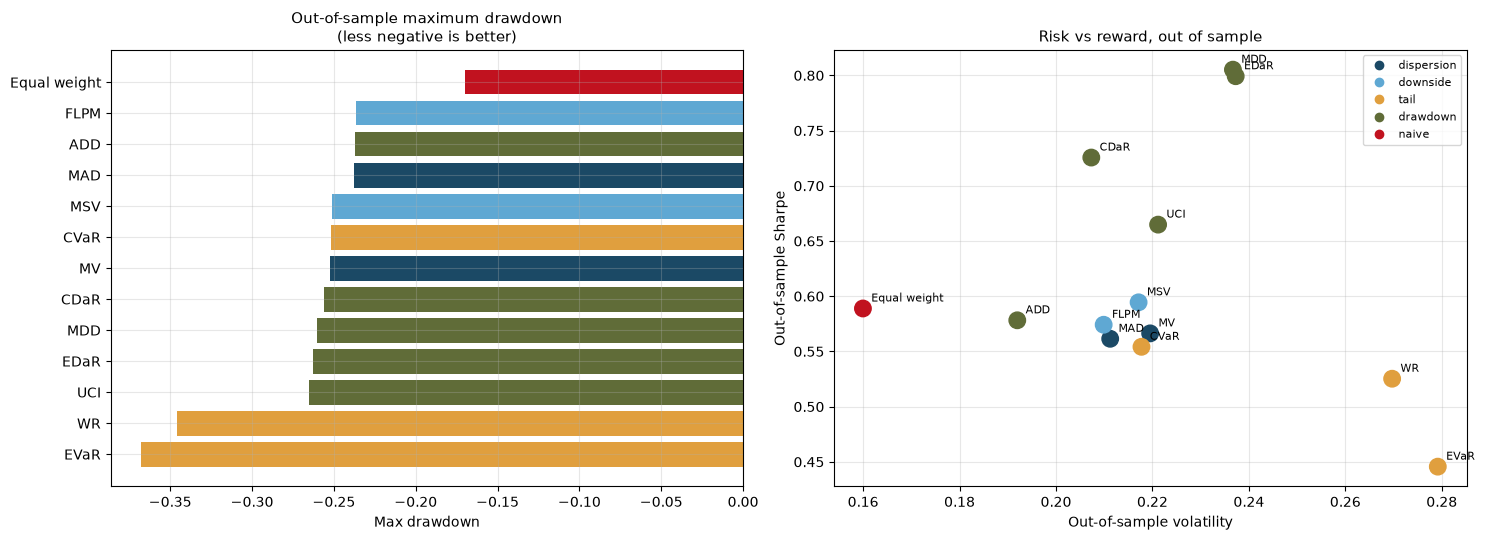

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colours = {"dispersion": "#1b4965", "downside": "#5fa8d3", "tail": "#e09f3e",
           "drawdown": "#606c38", "naive": "#c1121f"}
bar_c = [colours[f] for f in tourney["family"]]

order_dd = tourney.sort_values("Max drawdown")
axes[0].barh(order_dd.index, order_dd["Max drawdown"],
             color=[colours[f] for f in order_dd["family"]])
axes[0].set_title("Out-of-sample maximum drawdown\n(less negative is better)", fontsize=11)
axes[0].set_xlabel("Max drawdown")

axes[1].scatter(tourney["Volatility"], tourney["Sharpe"], s=140, c=bar_c, zorder=3)
for name, row in tourney.iterrows():
    axes[1].annotate(name, (row["Volatility"], row["Sharpe"]),
                     textcoords="offset points", xytext=(6, 5), fontsize=8)
axes[1].set_xlabel("Out-of-sample volatility"); axes[1].set_ylabel("Out-of-sample Sharpe")
axes[1].set_title("Risk vs reward, out of sample", fontsize=11)
handles = [plt.Line2D([0], [0], marker="o", ls="", color=c, label=f)
           for f, c in colours.items()]
axes[1].legend(handles=handles, fontsize=8, loc="best")
show()

### Reading the tournament

**The risk measures are genuinely different.** Look at the weights and the effective N — these
are not the same portfolio wearing thirteen labels. Switching `rm` materially changes what you
hold, which is the first thing worth establishing.

**Whether the drawdown family delivered shallower drawdowns is computed above, not asserted
here — and the answer moves with the sample.** Run this notebook on a different universe or a
different period and the verdict can flip. That is not a defect in the library; it is a
property of what these measures are.

Variance, MAD and CVaR are functions of the *distribution* of returns: shuffle the days into
any order and they are unchanged. Drawdown measures are functions of the *path*, because a
drawdown is a cumulative peak-to-trough decline that depends on sequencing. You have exactly
one historical path, so drawdown statistics are estimated far less reliably than variance from
the same data — and an estimate that noisy will not reproduce a clean ordering out of sample.

So the honest guidance is not "use CDaR for drawdown-averse clients and you are done". It is:
**the measure targets the right quantity, but the estimate is noisy, so verify on your own
data and do not promise more than the test supports.**

**And note where equal weight lands** in the table. On both universes I tested it was
competitive on Sharpe and at or near the best on drawdown, requiring no estimation whatsoever.
Whatever ordering your run produces, check that any optimised portfolio you are about to
recommend actually beats the naive one.

<details>
<summary><b>Why drawdown measures behave so differently</b></summary>

Variance, MAD and CVaR are all functions of the *distribution* of returns — reshuffle the days
in any order and they are unchanged. Drawdown measures are functions of the *path*: they
depend on the order in which returns arrive, because a drawdown is a cumulative peak-to-trough
decline.

That has a practical consequence. Path-dependent measures are far more sensitive to your
sample, because a given return distribution can produce wildly different worst drawdowns
depending on sequencing. With one historical path you get one realisation of that sequencing,
so drawdown estimates are noisier than variance estimates from the same data.

It also makes them harder to optimise: variance minimisation is a quadratic program with a
closed form, while CDaR minimisation is a linear program over the whole path. Riskfolio hides
this behind the same `rm=` argument, which is exactly what a good library should do.

</details>

---

# Module D — Where the risk actually sits

`rp.plot_risk_con` decomposes portfolio risk into per-asset contributions, with a reference
line for equal contribution. Lecture 3a showed that equal *weights* give wildly unequal
*risks*; here is the library's own view of the same idea, and it also groups by sector.

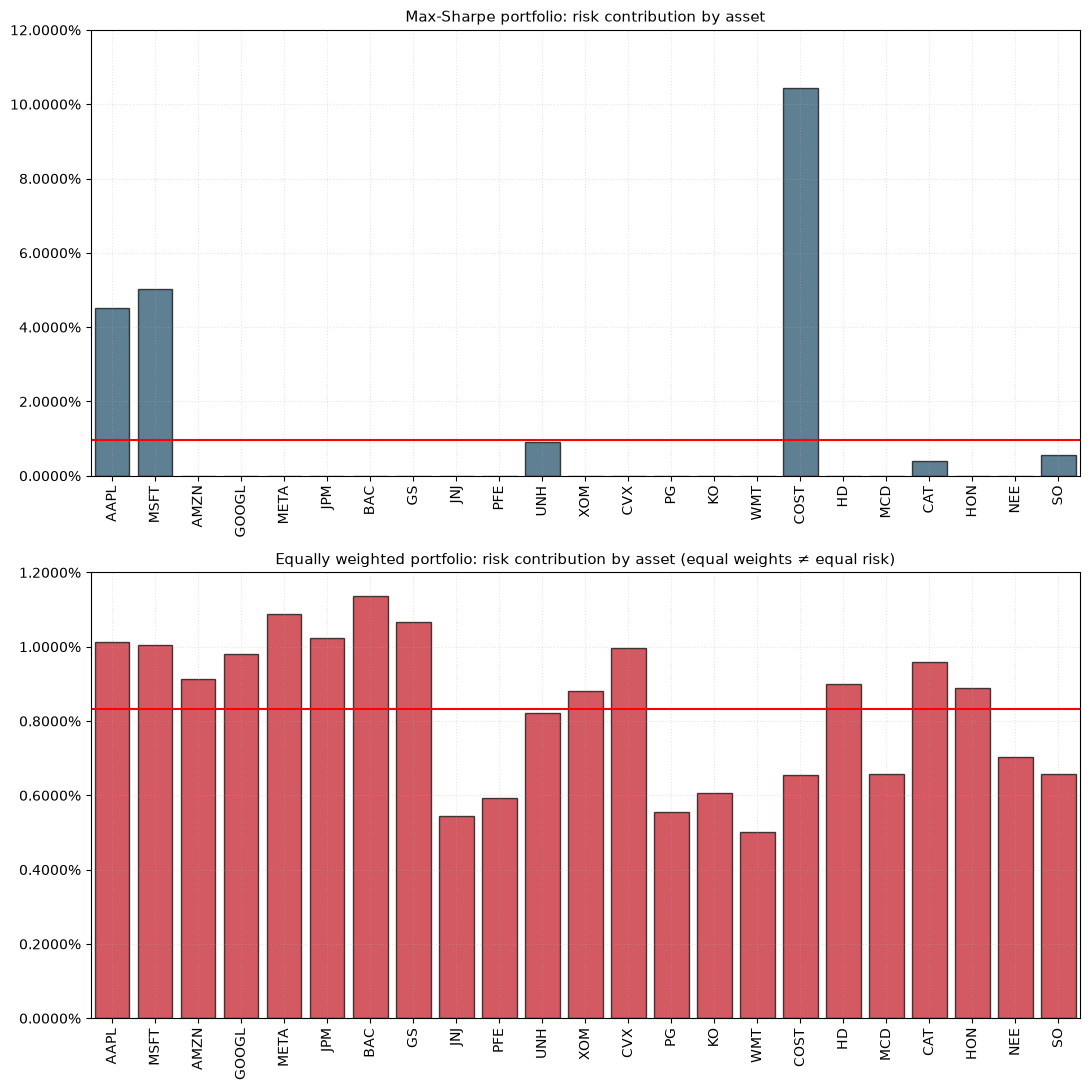

In [17]:
asset_classes = pd.DataFrame({"Assets": list(returns.columns),
                              "Sector": [sector_of.get(t, "Other") for t in returns.columns]})

fig, axes = plt.subplots(2, 1, figsize=(11, 11))
rp.plot_risk_con(w=w_sharpe, cov=port.cov, returns=returns, rm="MV", rf=0,
                 alpha=0.05, color="#1b4965", height=5, width=11,
                 t_factor=252, ax=axes[0])
axes[0].set_title("Max-Sharpe portfolio: risk contribution by asset", fontsize=11)

w_equal = pd.DataFrame({"weights": eq}, index=returns.columns)
rp.plot_risk_con(w=w_equal, cov=port.cov, returns=returns, rm="MV", rf=0,
                 alpha=0.05, color="#c1121f", height=5, width=11,
                 t_factor=252, ax=axes[1])
axes[1].set_title("Equally weighted portfolio: risk contribution by asset "
                  "(equal weights ≠ equal risk)", fontsize=11)
show()

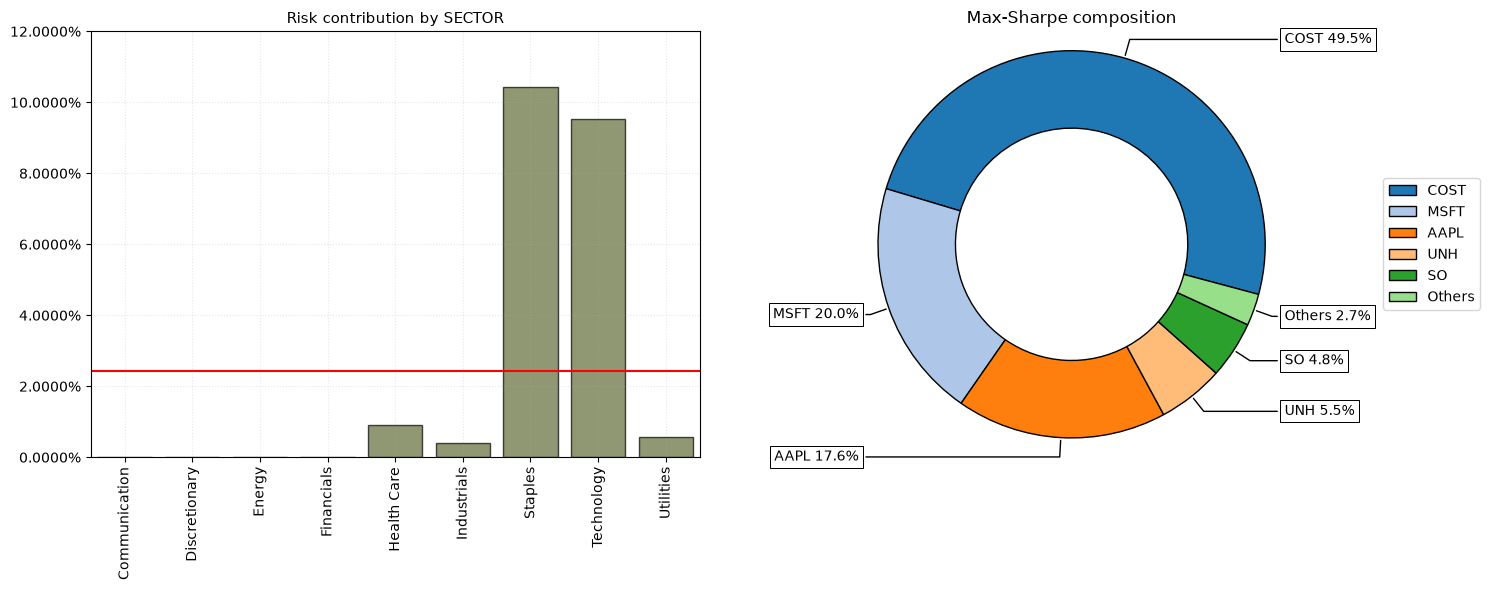

Max Sharpe   : largest risk contribution 47.7%  |   3 of 23 assets carry 90% of the risk
Equal weight : largest risk contribution  5.9%  |  20 of 23 assets carry 90% of the risk


In [18]:
# Risk contribution grouped by sector, and the pie chart for composition.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
rp.plot_risk_con(w=w_sharpe, cov=port.cov, returns=returns, rm="MV", rf=0,
                 asset_classes=asset_classes, classes_col="Sector",
                 color="#606c38", t_factor=252, ax=axes[0])
axes[0].set_title("Risk contribution by SECTOR", fontsize=11)
rp.plot_pie(w=w_sharpe, title="Max-Sharpe composition", others=0.03,
            nrow=25, cmap="tab20", ax=axes[1])
show()

def risk_contributions(w, cov):
    w = np.asarray(w).ravel()
    return w * (cov @ w) / (w @ cov @ w)

def risk_concentration(rc):
    """How many assets carry 90% of the risk? A ratio of max to min is useless here,
    because an unheld asset contributes ~0 and the ratio explodes."""
    ordered = np.sort(rc)[::-1]
    return int(np.searchsorted(np.cumsum(ordered), 0.90) + 1)

rc_s = risk_contributions(w_sharpe.values, port.cov.values)
rc_e = risk_contributions(eq, port.cov.values)
n_assets = len(rc_s)
print(f"Max Sharpe   : largest risk contribution {rc_s.max():5.1%}  |  "
      f"{risk_concentration(rc_s):2d} of {n_assets} assets carry 90% of the risk")
print(f"Equal weight : largest risk contribution {rc_e.max():5.1%}  |  "
      f"{risk_concentration(rc_e):2d} of {n_assets} assets carry 90% of the risk")

---

# Module C — Constraints as a mandate design language

Real portfolios come with rules: no more than 20% in any sector, no position above 10%, a
minimum holding size to keep the book manageable. Riskfolio expresses these through
`assets_constraints`, which takes a small specification table and returns the matrices the
optimiser needs.

The syntax is finicky and thinly documented, so here it is spelled out. Every constraint is a
row with these columns, and the ones you leave blank still have to exist.

In [19]:
def sector_constraint(max_weight, classes_col="Sector"):
    """Cap EVERY sector at max_weight. One row of Riskfolio's constraint table.

    Columns are fixed by the library -- all of them must be present even when unused:
      Disabled / Type / Set / Position / Sign / Weight /
      Type Relative / Relative Set / Relative / Factor
    """
    return pd.DataFrame({
        "Disabled": [False],
        "Type": ["All Classes"],       # apply to every class in the Set
        "Set": [classes_col],          # which column of asset_classes to group by
        "Position": [""],              # blank because Type is 'All Classes'
        "Sign": ["<="],
        "Weight": [max_weight],
        "Type Relative": [""], "Relative Set": [""], "Relative": [""], "Factor": [""],
    })


def build_frontier(cap=None, sector_cap=None, points=30, rets=None):
    """Efficient frontier under an optional per-asset cap and/or sector cap."""
    rets = returns if rets is None else rets
    p = rp.Portfolio(returns=rets)
    p.assets_stats(method_mu="hist", method_cov="ledoit")
    if cap is not None:
        p.upperlng = cap                       # maximum long weight per asset
    if sector_cap is not None:
        ac = pd.DataFrame({"Assets": list(rets.columns),
                           "Sector": [sector_of.get(t, "Other") for t in rets.columns]})
        A, B = rp.assets_constraints(sector_constraint(sector_cap), ac)
        p.ainequality, p.binequality = A, B
    f = p.efficient_frontier(model="Classic", rm="MV", points=points, rf=0, hist=True)
    return p, f


def frontier_stats(p, f):
    W = f.T.values
    r = (W @ p.mu.values.ravel()) * 252
    v = np.sqrt(np.einsum("ij,jk,ik->i", W, p.cov.values, W)) * np.sqrt(252)
    return r, v, r / v


scenarios = {
    "Unconstrained":            dict(),
    "Max 15% per asset":        dict(cap=0.15),
    "Max 20% per sector":       dict(sector_cap=0.20),
    "Both constraints":         dict(cap=0.15, sector_cap=0.20),
}

results, curves = [], {}
for name, kw in scenarios.items():
    try:
        p_, f_ = build_frontier(**kw)
        r_, v_, s_ = frontier_stats(p_, f_)
        curves[name] = (v_, r_)
        results.append({"Mandate": name, "Best Sharpe": np.nanmax(s_),
                        "Max reachable return": np.nanmax(r_),
                        "Lowest vol": np.nanmin(v_),
                        "Assets held (max-Sharpe pt)": int((f_.iloc[:, int(np.nanargmax(s_))] > 0.01).sum())})
    except Exception as e:
        print(f"  {name}: failed ({type(e).__name__}: {str(e)[:60]})")

cons_df = pd.DataFrame(results).set_index("Mandate")
display(cons_df.style.format({"Best Sharpe": "{:.2f}",
                              "Max reachable return": "{:.1%}",
                              "Lowest vol": "{:.1%}",
                              "Assets held (max-Sharpe pt)": "{:.0f}"}))

,Best Sharpe,Max reachable return,Lowest vol,Assets held (max-Sharpe pt)
Mandate,,,,
Unconstrained,1.21,31.0%,15.8%,6
Max 15% per asset,1.12,24.5%,15.9%,10
Max 20% per sector,1.10,23.8%,16.7%,8
Both constraints,1.08,23.2%,16.7%,10


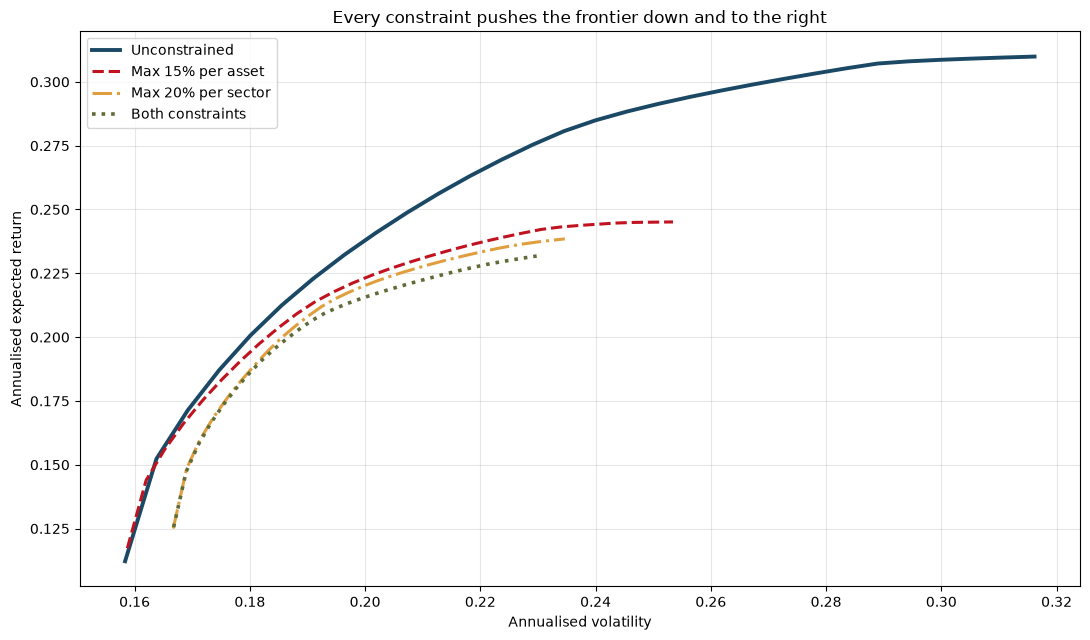

Cost of realism, measured on the IN-SAMPLE frontier:

  Max 15% per asset      Sharpe 1.21 -> 1.12  | max return 31.0% -> 24.5%
  Max 20% per sector     Sharpe 1.21 -> 1.10  | max return 31.0% -> 23.8%
  Both constraints       Sharpe 1.21 -> 1.08  | max return 31.0% -> 23.2%


In [20]:
plt.figure(figsize=(11, 6.5))
styles = {"Unconstrained": ("-", "#1b4965", 2.8),
          "Max 15% per asset": ("--", "#c1121f", 2.2),
          "Max 20% per sector": ("-.", "#e09f3e", 2.2),
          "Both constraints": (":", "#606c38", 2.6)}
for name, (v_, r_) in curves.items():
    ls, col, lw = styles.get(name, ("-", "grey", 2))
    plt.plot(v_, r_, ls, color=col, lw=lw, label=name)
plt.xlabel("Annualised volatility"); plt.ylabel("Annualised expected return")
plt.title("Every constraint pushes the frontier down and to the right")
plt.legend(); plt.grid(alpha=0.3); show()

base = cons_df.loc["Unconstrained"]
print("Cost of realism, measured on the IN-SAMPLE frontier:\n")
for name in cons_df.index[1:]:
    row = cons_df.loc[name]
    print(f"  {name:22s} Sharpe {base['Best Sharpe']:.2f} -> {row['Best Sharpe']:.2f}  "
          f"| max return {base['Max reachable return']:.1%} -> {row['Max reachable return']:.1%}")

### Reading the cost correctly

Every constraint moves the frontier down and to the right. That is guaranteed — you removed
options from a maximisation problem, so the optimum cannot improve. The interesting question
is *how much* you gave up, and the answer here is: **very little Sharpe, and a great deal of
reachable return.**

The reachable-return column collapses because the unconstrained frontier's upper end is that
corner solution from Module A — everything in one stock. Cap positions at 15% and that corner
becomes unreachable. You did not lose a portfolio anyone would have held; you lost a
mathematical artefact.

And now recall Lecture 3b, which measured the same constraints **out of sample** rather than
in: a 15% cap took out-of-sample Sharpe from 0.76 to 1.56. Put the two results side by side:

> **Constraints cost you in-sample and pay you out-of-sample.**

That is the whole argument for constrained optimisation in one line. The in-sample cost shown
above is the price of admission; the out-of-sample gain is what you bought. Anyone who
evaluates constraints only on the in-sample frontier will conclude they are pure loss, and
will be exactly wrong.

---

## The verdict

**Riskfolio-Lib is an excellent tool, and it will not save you from your inputs.**

What it does superbly:

- **Thirteen risk measures behind one argument.** Switching from variance to conditional
  drawdown at risk changes the optimisation from a quadratic to a linear program, and you
  never notice. The measures are coherent and deliver what they target.
- **Frontier plotting that repays attention.** `plot_frontier_area`, once sorted by sector,
  shows composition migrating from defensive to concentrated as risk rises — and shows that
  the top of every frontier is a corner solution.
- **A real constraint system.** `assets_constraints` expresses genuine mandates, and the
  frontier makes their cost visible.

What it cannot do:

- **Estimate the future.** Every optimisation above rests on a historical mean and covariance.
  Lectures 3b, 3c and 3d were about how badly that goes wrong.
- **Beat equal weighting reliably.** It did not here, on drawdown or on Sharpe.

### What breaks in production

**Single train/test split.** One split is one path. Lecture 3c's walk-forward protocol changed
the conclusion entirely; treat this notebook's rankings as illustrative, not decisive.

**Drawdown measures are path-dependent and therefore noisier.** They need more data than
variance to estimate at the same reliability, and you have exactly one historical path.

**`upperlng` is not the same as a general bound.** It caps long positions. Short constraints,
turnover budgets and cardinality limits need different machinery — see the exercises.

**Rate limits will bite again.** The loader retries, but if Yahoo throttles you persistently,
increase `pause`, reduce `batch_size`, or cache to CSV and stop re-downloading.

---

## Exercises

### Core

**C1 — Break the loader deliberately.** Add three invented tickers (`"ZZZZ"`, `"NOTREAL"`,
`"XYZ123"`) to `TICKERS` and re-run. Does the notebook still produce a portfolio? Read the
coverage report and confirm each is correctly categorised.

**C2 — Coverage threshold.** Set `min_coverage=0.5` and re-run. Which additional tickers
survive, and what happens to the number of common dates? Explain the trade-off between
universe breadth and sample length.

**C3 — Choose a measure for a client.** A pension trustee says: "I don't mind volatility, but
a drawdown beyond 20% would force us to de-risk at the worst time." Pick the appropriate `rm`,
justify it from the tournament table, and report what that portfolio actually delivered out of
sample.

**C4 — Read the area plot.** Using `plot_frontier_area`, identify the frontier point at which
the portfolio stops being meaningfully diversified (say, fewer than eight assets above 1%).
What return is that, and would you accept the concentration to get it?

### Stretch

**S1 — Walk-forward tournament.** Replace the single split with a rolling scheme: estimate on
252 days, hold 21, roll. Re-run the risk-measure tournament. Does the drawdown family still
deliver, and does equal weight still win?

**S2 — A full mandate.** Build a constraint set with sector caps at 25%, a per-asset maximum of
12%, and a *minimum* of 2% for any held position. Compare the frontier to the unconstrained
case and report the cost in basis points of Sharpe.

**S3 — Cardinality.** Riskfolio supports limiting the *number* of holdings (`card`). Constrain
the portfolio to at most 10 assets and compare with the 25-asset optimum. Is a concentrated
portfolio chosen deliberately better or worse than one that concentrated by accident?

**S4 — Kelly in practice.** Compute the max-Sharpe and the Kelly-optimal portfolios, then
compare their *realised compound growth* out of sample. Does the theoretically superior
objective win in practice, and what does your answer depend on?

**S5 — Cache and compare.** Extend `download_prices` to write a CSV cache and read from it when
present. Then re-run the whole notebook offline and confirm you get identical results — the
basic requirement for reproducible research.

---

## Summary

| | |
|---|---|
| **The data fix** | `yf.download` returns failed tickers as all-NaN columns; `.dropna()` on rows then deletes everything. Drop empty **columns first**, retry failures, report coverage |
| **The frontier** | Diversified at the low-risk end, a single-asset corner solution at the high-risk end. Sort `plot_frontier_area` by sector to see it |
| **Risk measures** | Genuinely different portfolios, not relabelled ones — but path-dependent measures are noisy, so verify out of sample rather than assuming |
| **Constraints** | Cost you in-sample, pay you out-of-sample |

1. **A robust loader is not optional.** Two throttled tickers silently emptied a 25-asset
   dataset. The fix is ordering: empty columns before empty rows.
2. **"Possibly delisted" usually means "rate limited".** Retry before you believe it.
3. **`plot_frontier_area` sorted by sector** turns a colour chart into an argument about how
   portfolios change as risk rises.
4. **Pick the risk measure to match the client's fear** — then verify out of sample that it
   actually delivered, because drawdown measures are path-dependent and noisy.
5. **Constraints are regularisation.** The in-sample frontier shows their cost; only an
   out-of-sample test shows their value.